In [1]:
import os
import sys
import pdfplumber
import polars as pl
from pydantic import BaseModel, field_validator
from IPython.display import display

# Add parent directory to Python path
notebook_dir = os.path.dirname(os.path.abspath(''))
parent_dir = os.path.dirname(notebook_dir)
if parent_dir not in sys.path:
	sys.path.append(parent_dir)

from src.utils.converter import format_luas, format_number

In [2]:
current_path = os.getcwd()
script_dir = os.path.dirname(current_path)
input_dir = os.path.join(script_dir, "datas")
print(current_path)
print(input_dir)

d:\Develop\repo\db-wilayah-indonesia\src\notebooks
d:\Develop\repo\db-wilayah-indonesia\src\datas


In [3]:
file_name = "Keputusan_Menteri_Dalam_Negeri_Nomor_300.2.2-2138_Tahun_2025.pdf"
pdf_path = os.path.join(input_dir, file_name)

In [4]:
kabupaten_kota_index_settings = {
    "vertical_strategy": "lines",
    "horizontal_strategy": "text",
    "snap_y_tolerance": 7,
    "intersection_y_tolerance": 500,
    "intersection_x_tolerance": 500,
}

In [5]:
start_page_index = 609
end_page_index = 610

page_numbers = list(range(start_page_index, end_page_index + 1))
print(page_numbers)

[609, 610]



Processing page 1:


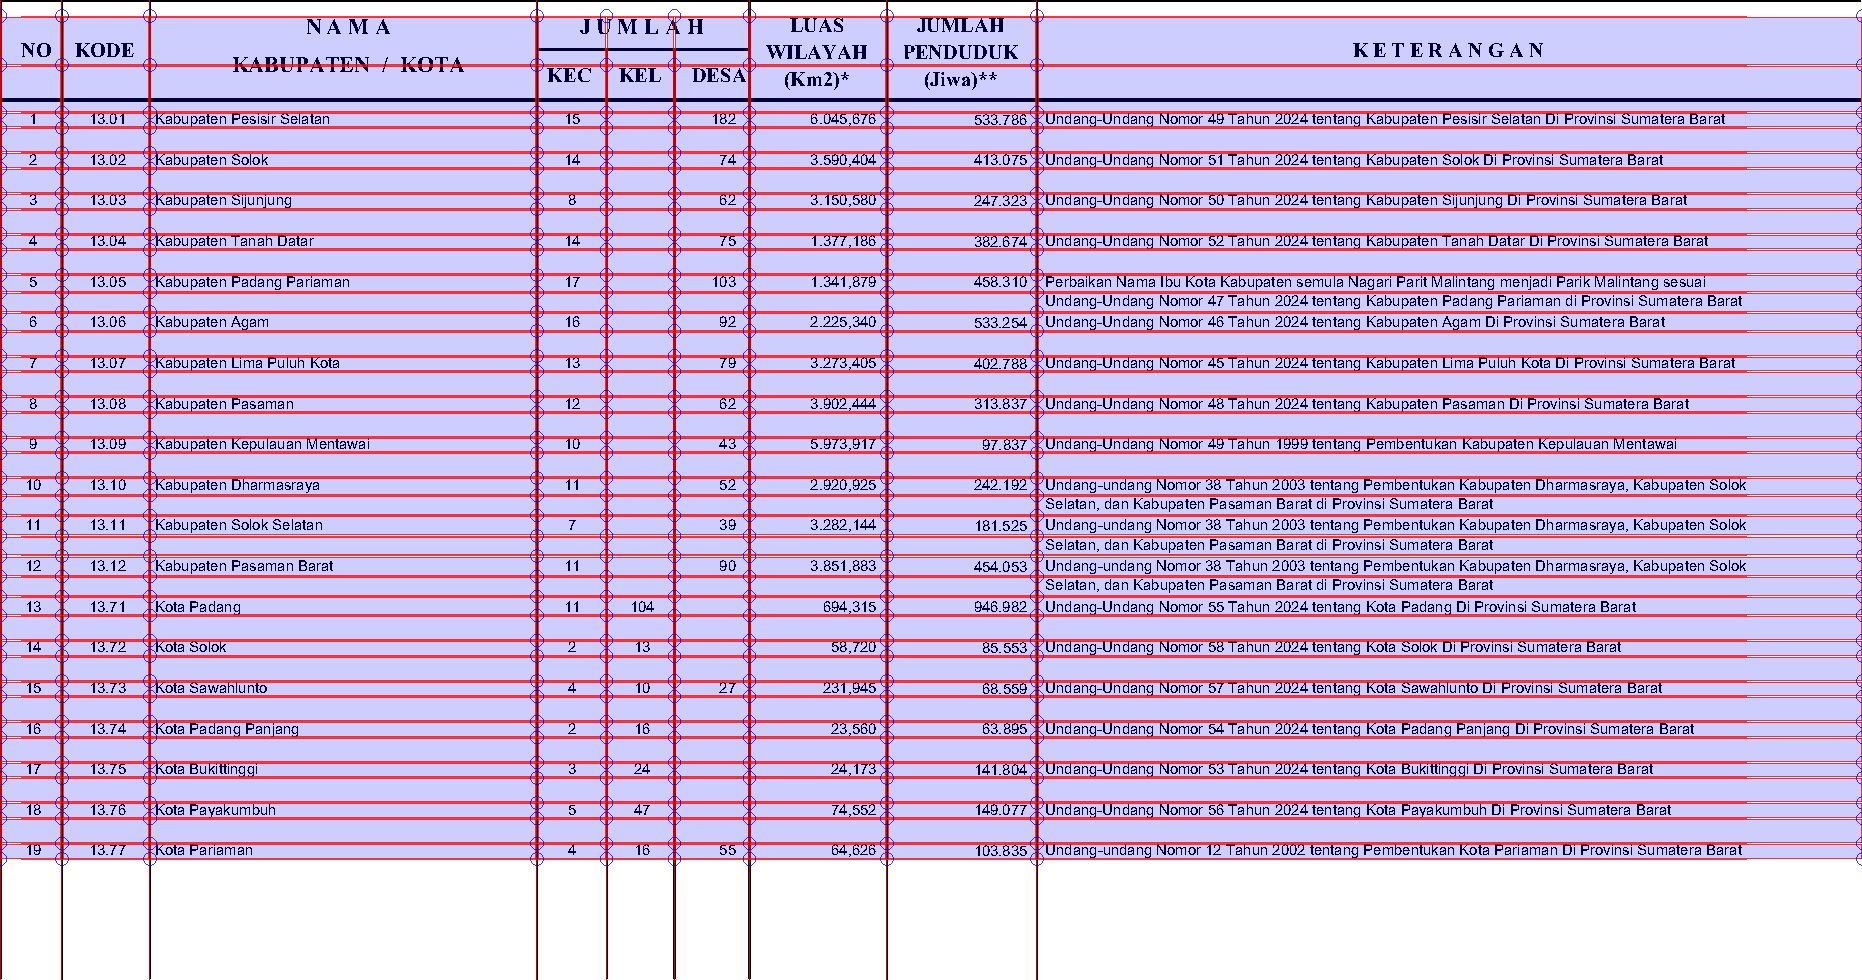


Processing page 2:


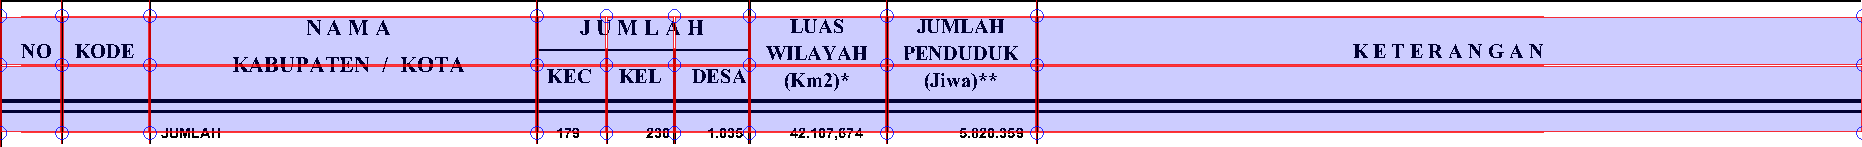

In [6]:
with pdfplumber.open(pdf_path, pages=page_numbers) as pdf:
    if pdf.pages:
        for i, page in enumerate(pdf.pages):
            print(f"\nProcessing page {i + 1}:")
            table = page.find_table()
            if table is not None and table.bbox is not None:
                table_bbox = table.bbox
                the_table = page.crop(table_bbox)
                im = the_table.to_image(resolution=150)
                table_extract = im.debug_tablefinder(kabupaten_kota_index_settings)
                value_table = the_table.extract_table(kabupaten_kota_index_settings)
                display(table_extract)
                replacement_value = ""

In [7]:
raw_records = []

with pdfplumber.open(pdf_path, pages=page_numbers) as pdf:
    if pdf.pages:

        for i, page in enumerate(pdf.pages):
            table = page.extract_table(kabupaten_kota_index_settings)
            if table is not None:
                for row in table:
                    if any(row) :
                        raw_records.append(row)
                        print(len(row))

9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9
9


In [8]:
def are_sublist_lengths_same(main_list):
    if not main_list:
        return True

    lengths = {len(sublist) for sublist in main_list}
    if len(lengths) == 1:
        return "Ok"
    else:
        raise ValueError("Not same length")


In [9]:
print(are_sublist_lengths_same(raw_records))
print(len(raw_records[0]))

Ok
9


In [10]:
raw_records

[['', '', '', '', '', '', '', '609', ''],
 ['B. Ri',
  'ncian Ko',
  'de dan Data Wilayah Administrasi Pe',
  'merint',
  'ahan K',
  'abupat',
  'en/Kota Per',
  'Provinsi Seluru',
  'h Indonesia'],
 ['c.', 'Provinsi', 'Sumatera Barat', '', '', '', '', '', ''],
 ['NO',
  'KODE',
  'N A M A\nKABUPATEN / KOTA',
  'J U',
  'M L A',
  'H',
  'LUAS\nWILAYAH',
  'JUMLAH\nPENDUDUK',
  'K E T E R A N G A N'],
 ['', '', '', 'KEC', 'KEL', 'DESA', '(Km2)*', '(Jiwa)**', ''],
 ['1',
  '13.01',
  'Kabupaten Pesisir Selatan',
  '15',
  '',
  '182',
  '6.045,676',
  '533.786',
  'Undang-Undang Nomor 49 Tahun 2024 tentang Kabupaten Pesisir Selatan Di Provinsi Sumatera Barat'],
 ['2',
  '13.02',
  'Kabupaten Solok',
  '14',
  '',
  '74',
  '3.590,404',
  '413.075',
  'Undang-Undang Nomor 51 Tahun 2024 tentang Kabupaten Solok Di Provinsi Sumatera Barat'],
 ['3',
  '13.03',
  'Kabupaten Sijunjung',
  '8',
  '',
  '62',
  '3.150,580',
  '247.323',
  'Undang-Undang Nomor 50 Tahun 2024 tentang Kabupaten Sij

In [11]:
class RegencyIndexData(BaseModel):
    no: int
    kode_kabupaten_kota: str
    kabupaten_kota: str
    jumlah_kecamatan: int
    jumlah_kelurahan: int
    jumlah_desa: int
    luas_wilayah_km2: float
    jumlah_penduduk: int
    keterangan: str

    @field_validator(
        "no",
        "jumlah_kecamatan",
        "jumlah_kelurahan",
        "jumlah_desa",
        "jumlah_penduduk",
        mode="before",
    )
    @classmethod
    def validate_int_fields(cls, v):
        if v is None or v == "":
            return 0
        return int(format_number(v))

    @field_validator("luas_wilayah_km2", mode="before")
    @classmethod
    def validate_float_fields(cls, v):
        if v is None or v == "":
            return 0.0
        return float(format_luas(v))

    @field_validator("kode_kabupaten_kota", "kabupaten_kota", "keterangan", mode="before")
    @classmethod
    def validate_str_fields(cls, v):
        return str(v) if v else ""

In [12]:
clean_records = []

i = 0
while i < len(raw_records):
    row = raw_records[i]
    if len(row) >= 9 and None not in row:
        first_cell = str(row[0]).strip() if row[0] else ""
        if first_cell and first_cell.isdigit():
            # Start of data row
            keterangan = str(row[8]) if row[8] else ""
            i += 1
            # Merge continuation rows
            while i < len(raw_records):
                next_row = raw_records[i]
                if (
                    len(next_row) >= 9
                    and None not in next_row
                    and str(next_row[0]).strip() == ""
                    and all(str(cell).strip() == "" for cell in next_row[:8])
                ):
                    keterangan += " " + str(next_row[8]) if next_row[8] else ""
                    i += 1
                else:
                    break

            try:
                # Create data with full keterangan
                data = RegencyIndexData(
                    no=row[0],
                    kode_kabupaten_kota=row[1],
                    kabupaten_kota=row[2],
                    jumlah_kecamatan=row[3],
                    jumlah_kelurahan=row[4],
                    jumlah_desa=row[5],
                    luas_wilayah_km2=row[6],
                    jumlah_penduduk=row[7],
                    keterangan=keterangan,
                )
                clean_records.append(data)
            except (ValueError, IndexError) as e:
                raise ValueError(f"Failed to parse table row {row}: {e}")

        else:
            i += 1
    else:
        i += 1


In [13]:
pl.DataFrame([data.model_dump() for data in clean_records])

no,kode_kabupaten_kota,kabupaten_kota,jumlah_kecamatan,jumlah_kelurahan,jumlah_desa,luas_wilayah_km2,jumlah_penduduk,keterangan
i64,str,str,i64,i64,i64,f64,i64,str
1,"""13.01""","""Kabupaten Pesisir Selatan""",15,0,182,6045.676,533786,"""Undang-Undang Nomor 49 Tahun 2…"
2,"""13.02""","""Kabupaten Solok""",14,0,74,3590.404,413075,"""Undang-Undang Nomor 51 Tahun 2…"
3,"""13.03""","""Kabupaten Sijunjung""",8,0,62,3150.58,247323,"""Undang-Undang Nomor 50 Tahun 2…"
4,"""13.04""","""Kabupaten Tanah Datar""",14,0,75,1377.186,382674,"""Undang-Undang Nomor 52 Tahun 2…"
5,"""13.05""","""Kabupaten Padang Pariaman""",17,0,103,1341.879,458310,"""Perbaikan Nama Ibu Kota Kabupa…"
…,…,…,…,…,…,…,…,…
15,"""13.73""","""Kota Sawahlunto""",4,10,27,231.945,68559,"""Undang-Undang Nomor 57 Tahun 2…"
16,"""13.74""","""Kota Padang Panjang""",2,16,0,23.56,63895,"""Undang-Undang Nomor 54 Tahun 2…"
17,"""13.75""","""Kota Bukittinggi""",3,24,0,24.173,141804,"""Undang-Undang Nomor 53 Tahun 2…"
